# study_v2_cat — joint categorical GP (Method C) & the 3-way comparison

**Method C**: ONE `MixedSingleTaskGP` + `CategoricalKernel` over `(x1, category)` — the
botorch analogue of LVGP's cross-category sharing (vs `study_v2_gp`'s 5 *independent* GPs).
Same problem, same 12-config × n_rep{3,5,10} × 30-seed sweep. The **only** code difference
from study_v2_gp is the GP (`utils/model.py`); problem, acquisitions, noise model, and BO
loop are identical, so the comparison isolates exactly that.

Plotting reuses study_v2's `StudyResults` gallery, plus `compare_studies_multi` for the
3-way overlay (LVGP vs per-category GP vs categorical GP).

> **Kernel:** ml_gp_env (botorch 0.14). Run `python run_sweep.py` first. Convention matches
> study_v2/analysis.ipynb: `%matplotlib inline` + bare `plot_*()` calls.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline

from utils import StudyResults, compare_studies, compare_studies_multi, problem

cat  = StudyResults.load("../results")                 # this study (categorical GP, Method C)
gp   = StudyResults.load("../../study_v2_gp/results")  # per-category GP  (study_v2_gp)
lvgp = StudyResults.load("../../study_v2/results")     # LVGP             (study_v2, .mat)
print(f"categorical GP: {len(cat.runs)} | per-category GP: {len(gp.runs)} | LVGP: {len(lvgp.runs)} runs")

categorical GP: 1080 | per-category GP: 1080 | LVGP: 1080 runs


In [2]:
# final-iteration summary for the categorical-GP study
cat.summary()

1080 runs | 12 configs | n_rep=[3, 5, 10] | seeds=30 | ground-truth min = 0.465


## Standard gallery for the categorical-GP study
(Same plots as the other two studies — `save_all_plots.py` writes the whole tree.)

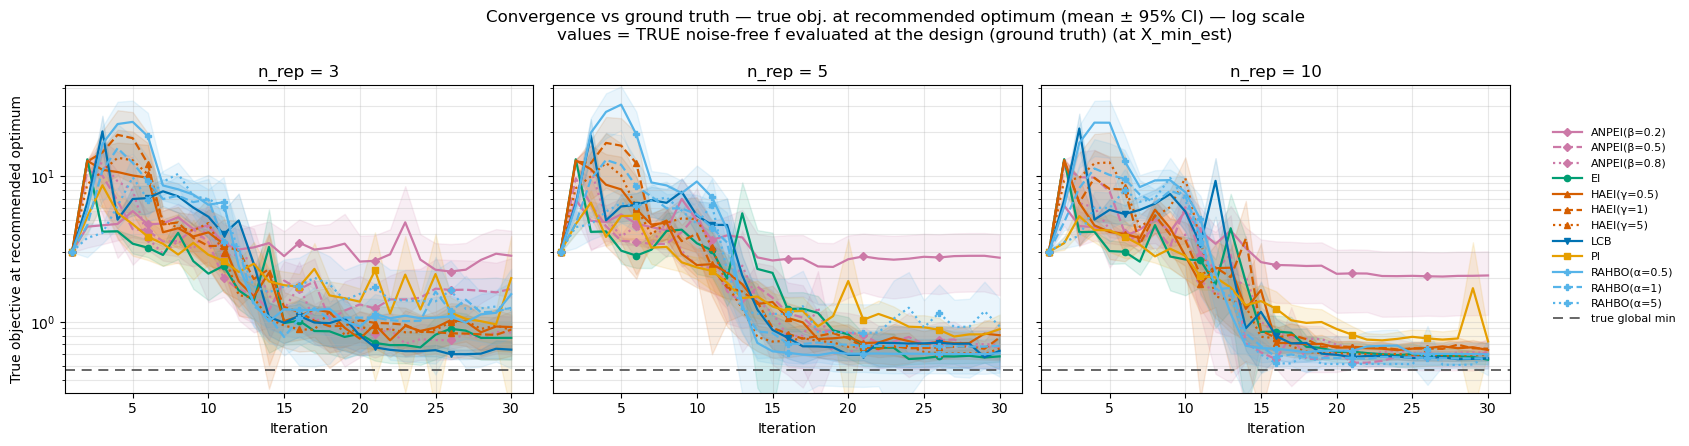

In [3]:
cat.plot_convergence_true(log=True)

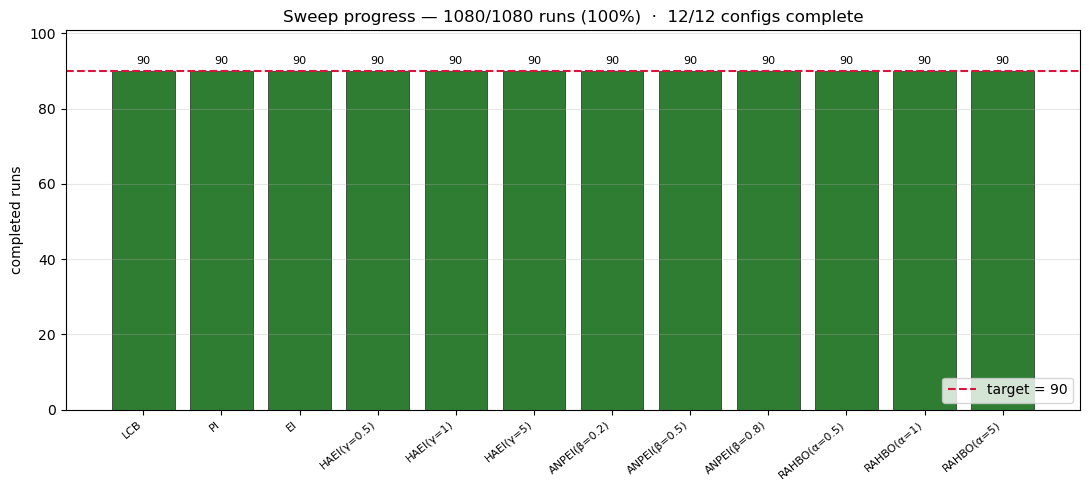

In [4]:
cat.plot_progress() 

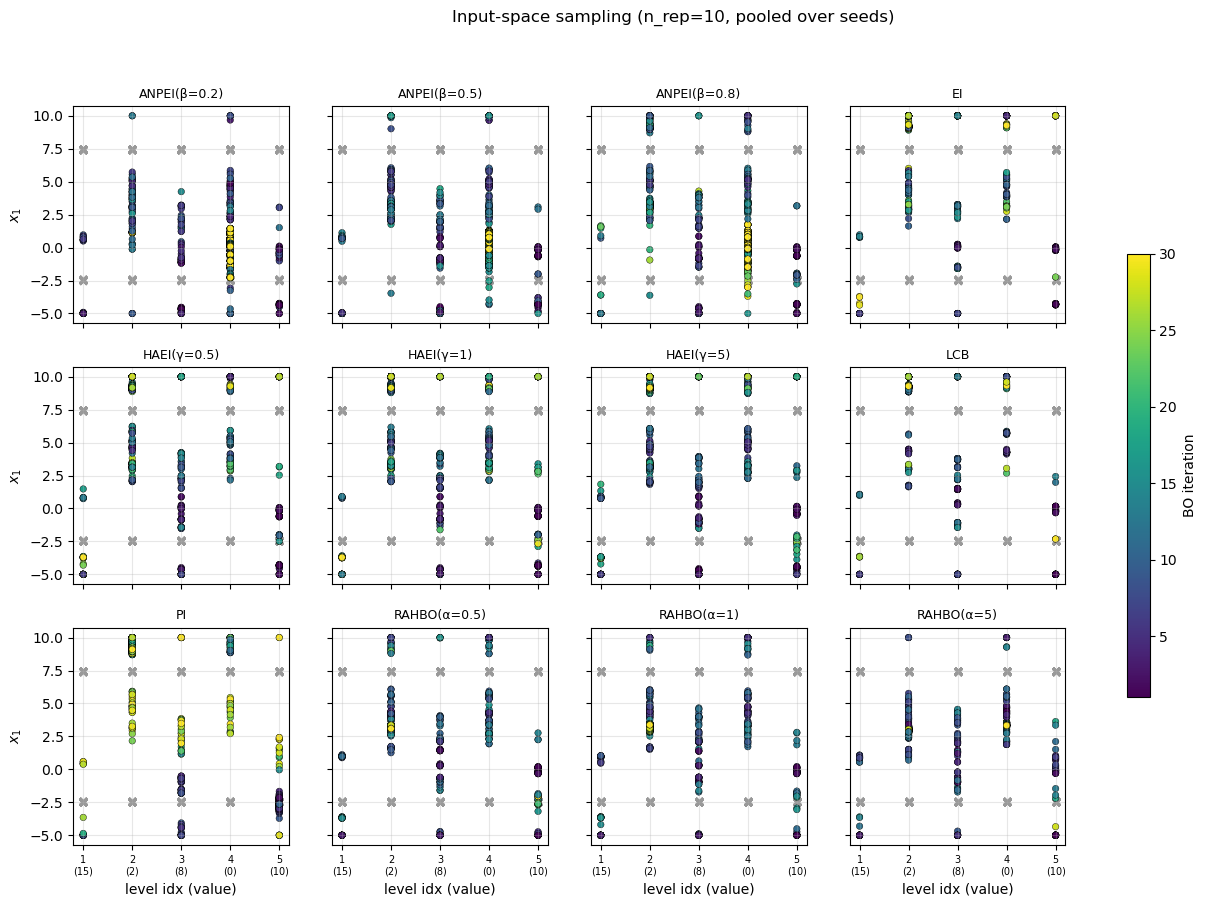

In [5]:
cat.plot_input_space(n_rep=10)

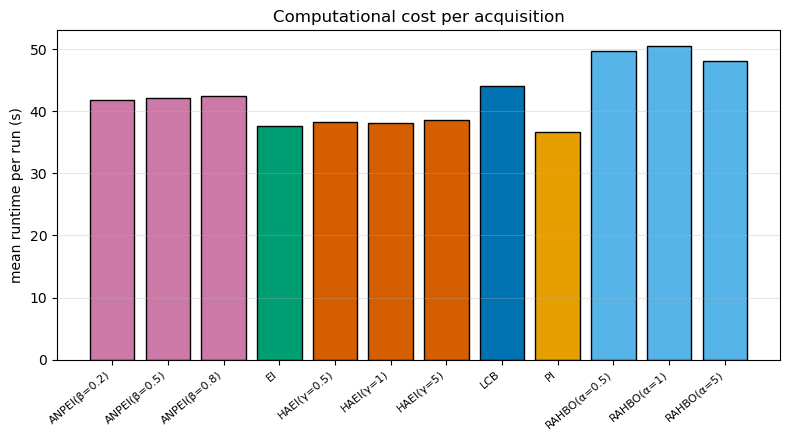

In [6]:
cat.plot_runtime()    # note: joint GP is pricier to fit than 5 independent GPs

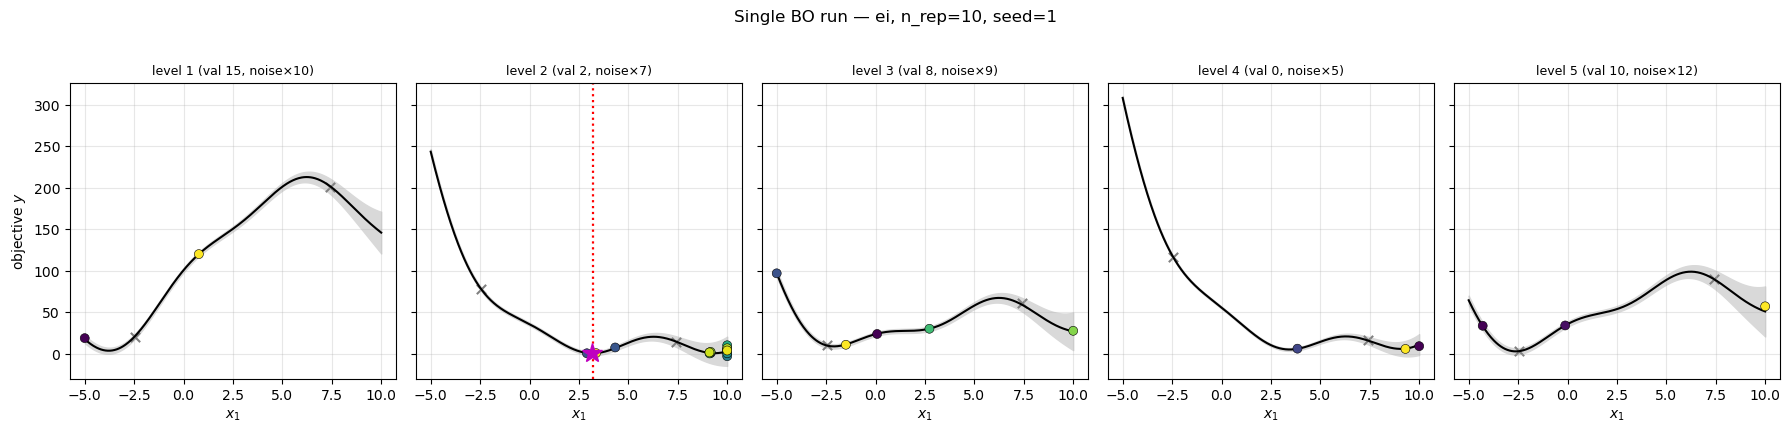

In [7]:
cat.plot_single_run("ei/nrep10/seed01.npz")

## The 3-way comparison (the point of Method C)
One subplot per acquisition; one line per study. The question: does a **single joint
categorical GP** match LVGP's cross-category sharing, and how far does the **per-category**
baseline fall behind?

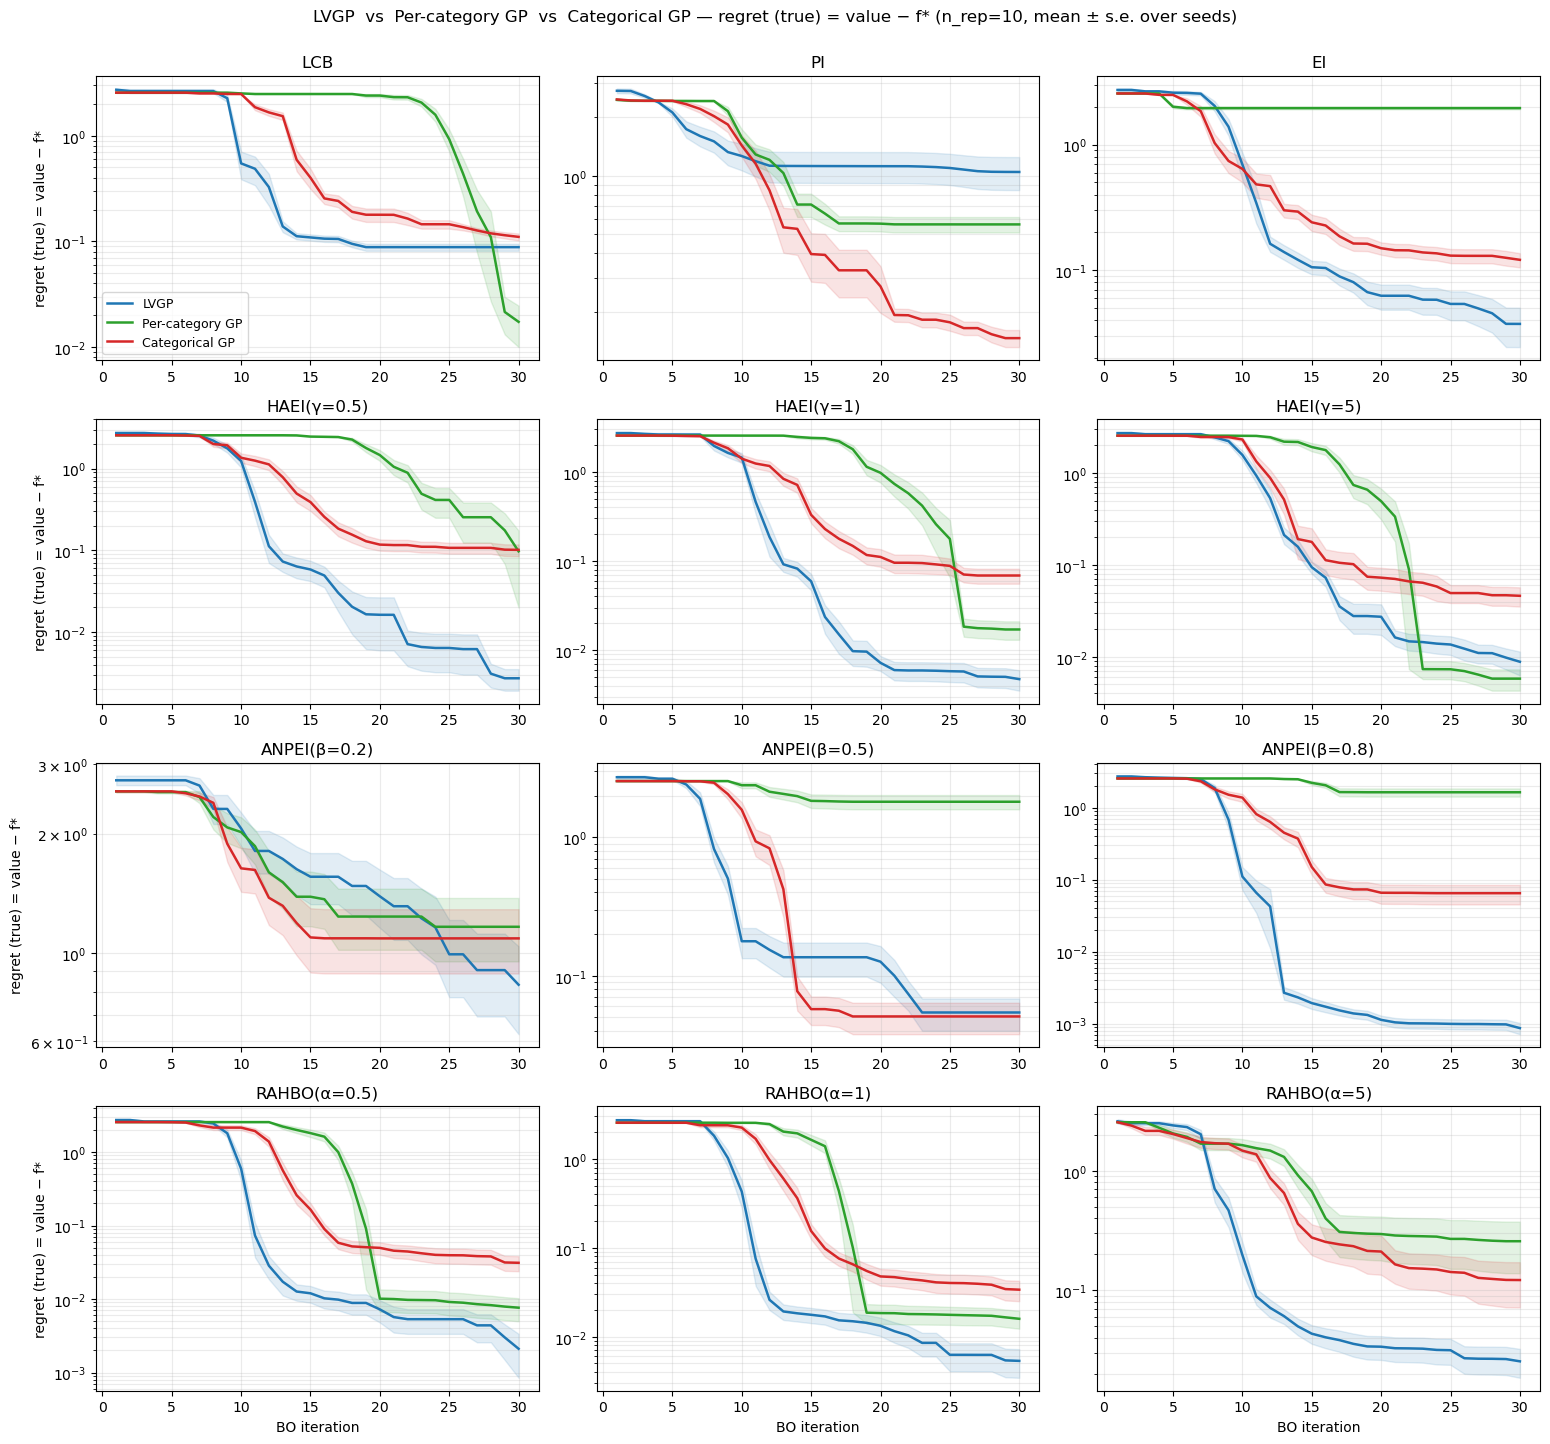

In [8]:
compare_studies_multi([(lvgp, "LVGP"), (gp, "Per-category GP"), (cat, "Categorical GP")],
                      is_ground_truth=True, n_rep=10)

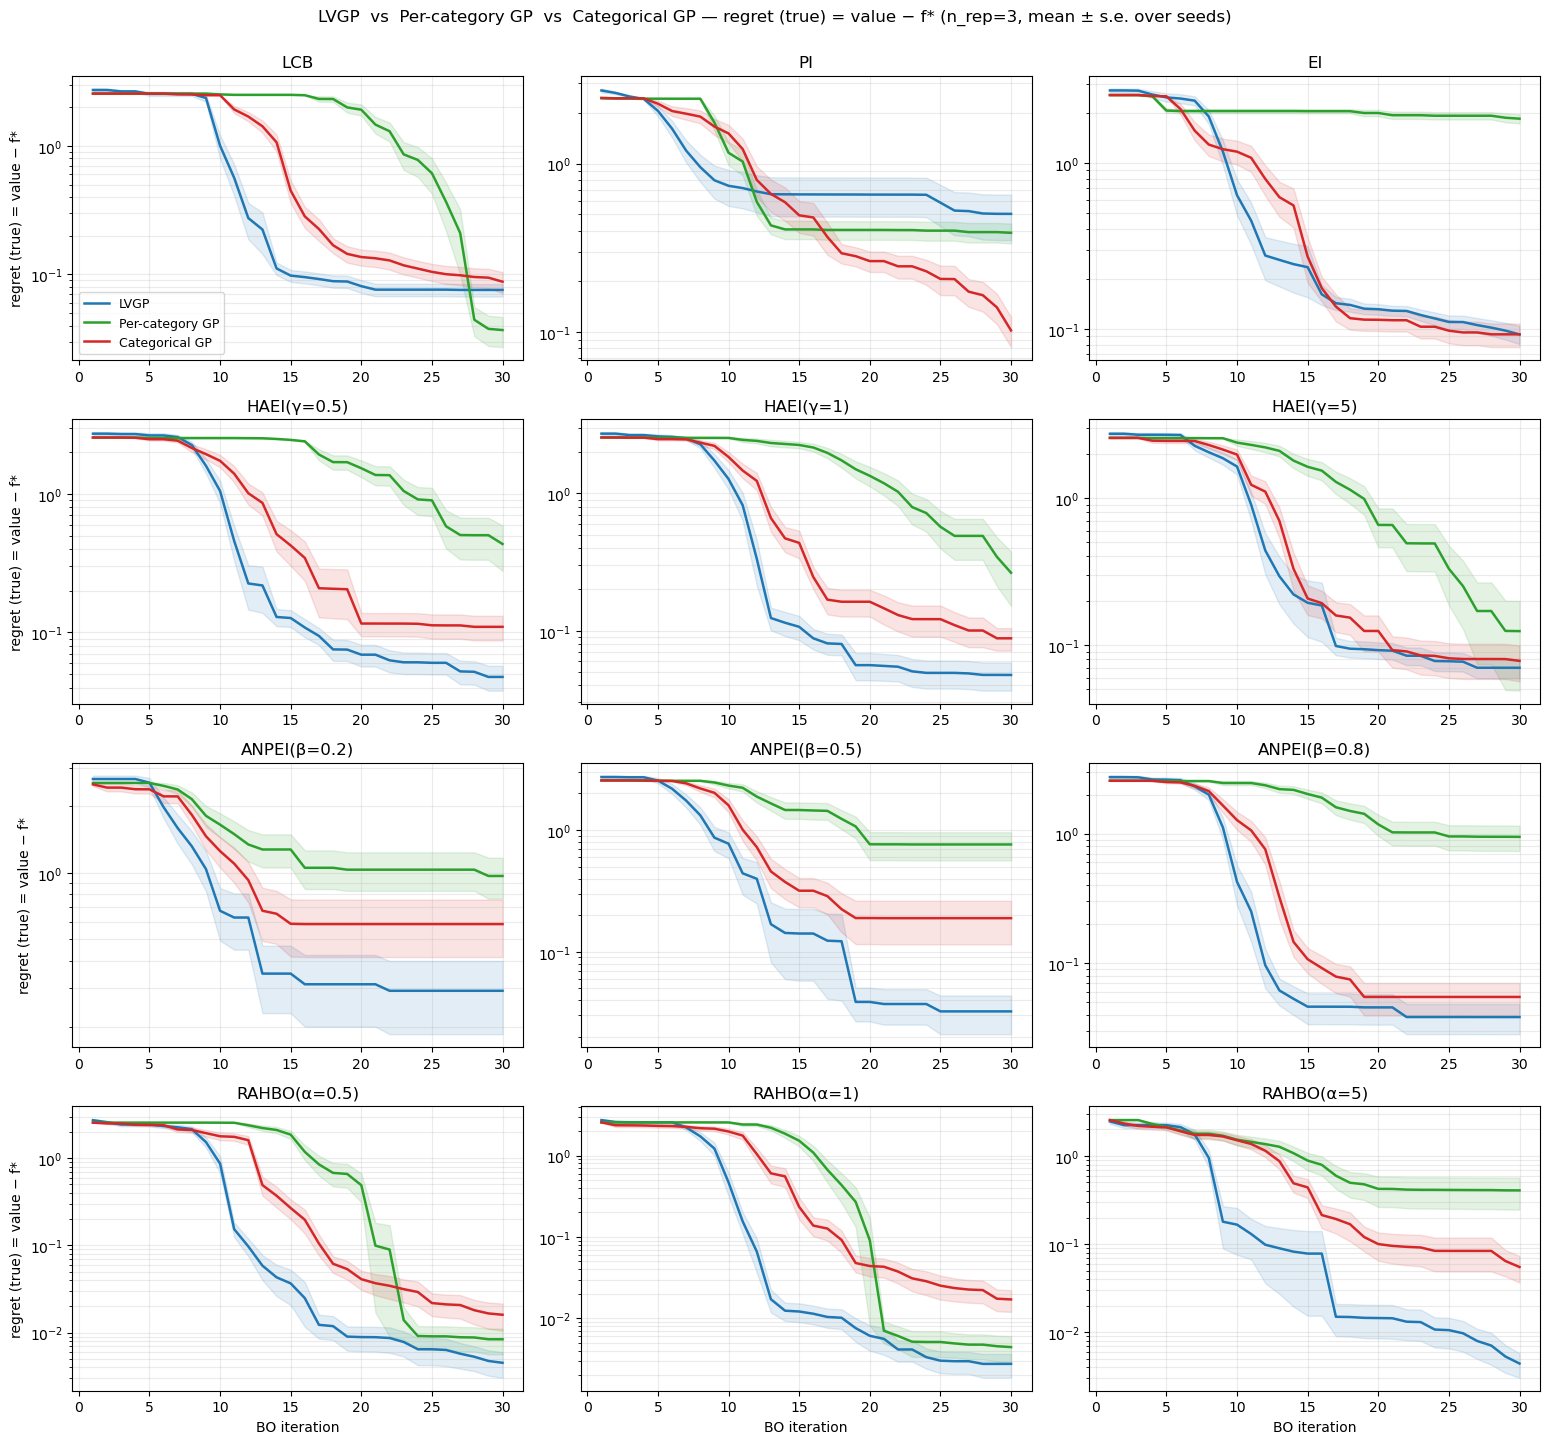

In [9]:
compare_studies_multi([(lvgp, "LVGP"), (gp, "Per-category GP"), (cat, "Categorical GP")],
                      is_ground_truth=True, n_rep=3)

### Pairwise (categorical GP vs each)

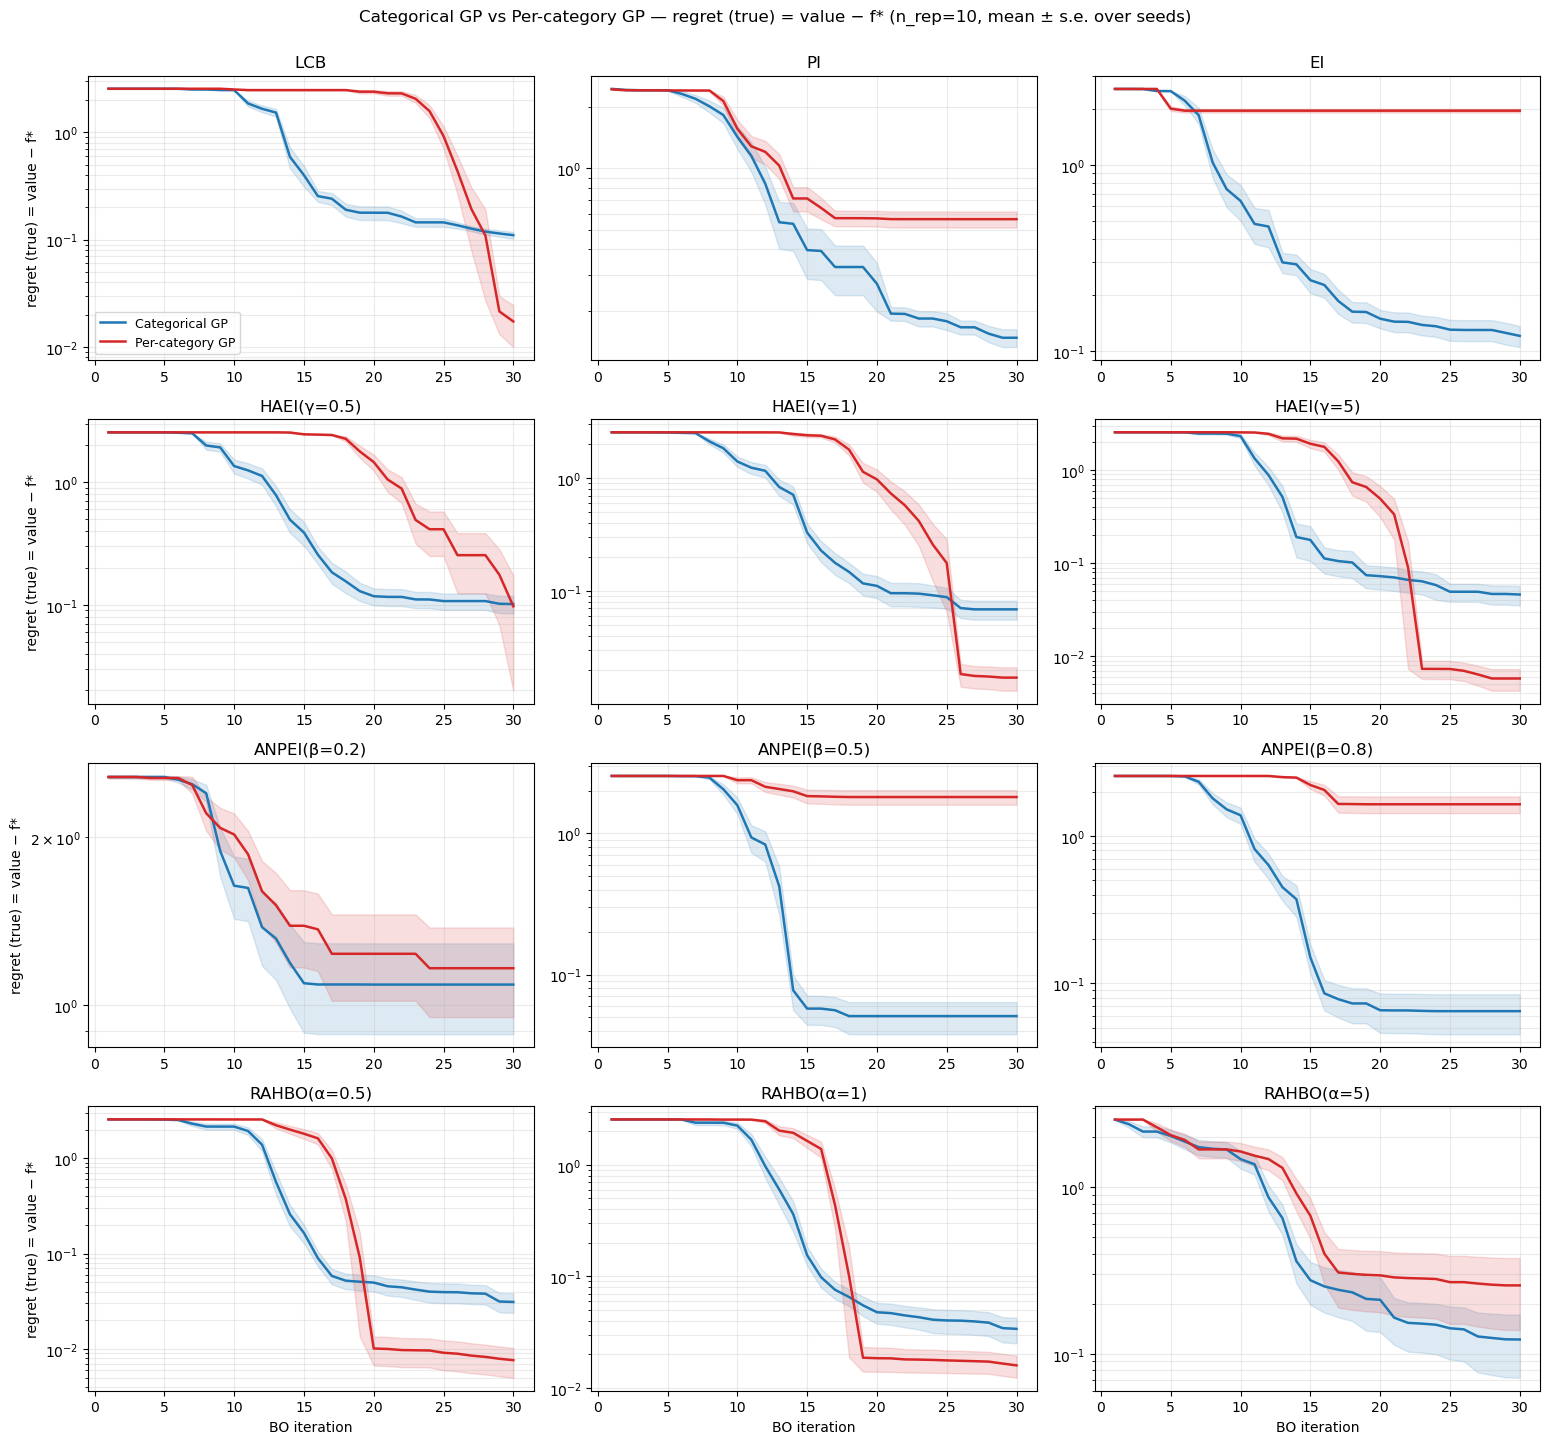

In [10]:
compare_studies(cat, gp,   is_ground_truth=True, n_rep=10, labels=("Categorical GP", "Per-category GP"))

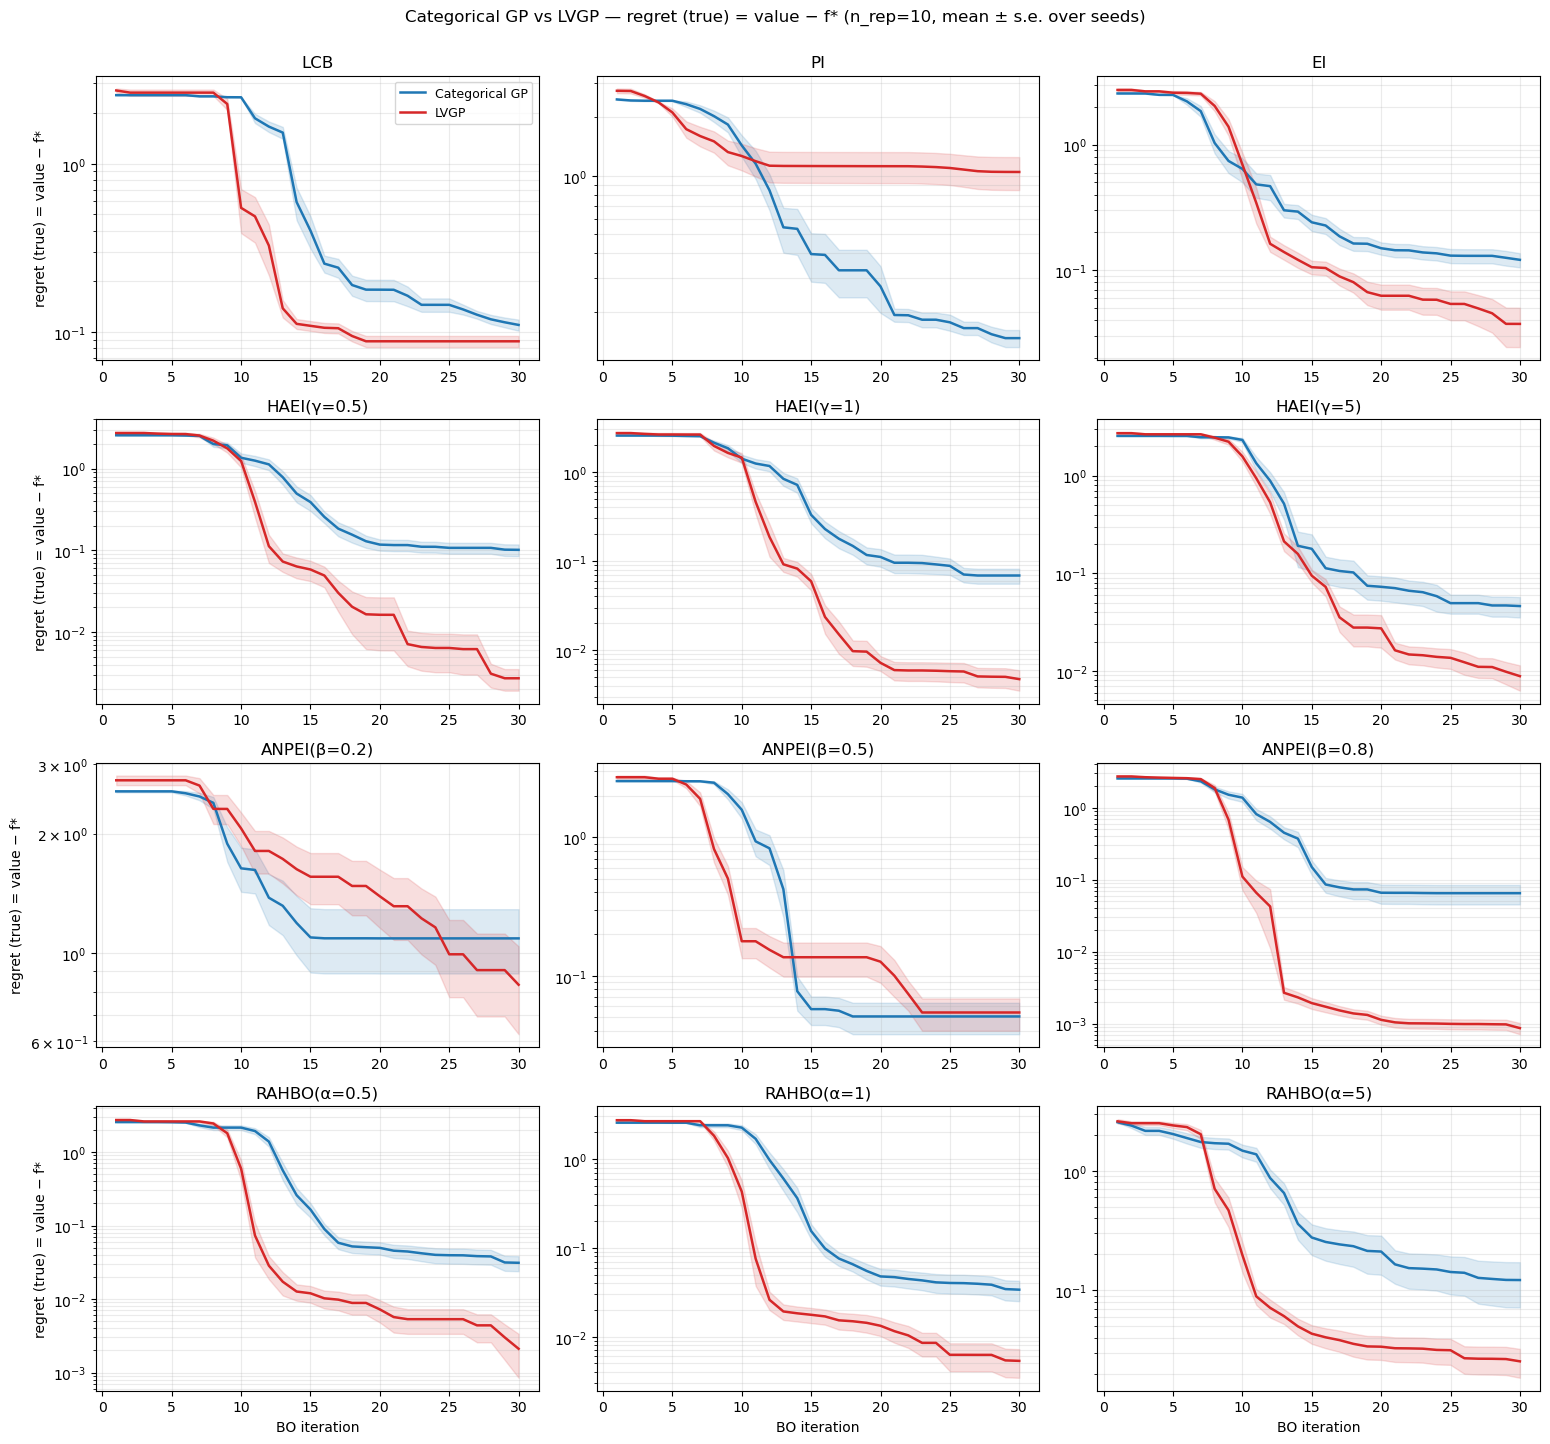

In [11]:
compare_studies(cat, lvgp, is_ground_truth=True, n_rep=10, labels=("Categorical GP", "LVGP"))

## Regenerate every figure in `plots/` in one call
Runs `save_all_plots.main()` — main + analysis + single_runs + comparison — so you don't call each plot by hand. Reads `results/`, never re-runs the optimization. (Backend stays inline; figures are saved to `plots/`, not shown here.)

In [12]:
import importlib, save_all_plots
importlib.reload(save_all_plots)   # pick up any edits
save_all_plots.main()              # writes plots/{main,analysis,single_runs,comparison}/

loaded 1080 runs
plots/main:
  saved plots/main/0_progress.png
  saved plots/main/0b_initial_doe.png
  saved plots/main/1_convergence_noisy.png
  saved plots/main/1b_convergence_true_log.png
  saved plots/main/1b_convergence_true_zoom.png
  saved plots/main/1c_x1_convergence_noisy.png
  saved plots/main/1c_x1_convergence_true.png
  saved plots/main/1d_x1_distribution_noisy.png
  saved plots/main/1d_x1_distribution_true.png
  saved plots/main/1e_x1_landing.png
  saved plots/main/2_input_space.png
  saved plots/main/2b_best_designs_noisy.png
  saved plots/main/2b_best_designs_true.png
  saved plots/main/3_level_histogram.png
  saved plots/main/4_objective_variance_noisy.png
  saved plots/main/4_objective_variance_true.png
  saved plots/main/5_final_boxplots_noisy.png
  saved plots/main/5_final_boxplots_true.png
  saved plots/main/6_best_per_category_noisy.png
  saved plots/main/6_best_per_category_true.png
plots/analysis:
  saved plots/analysis/A_simple_regret_noisy.png
  saved plots/ana